In [ ]:
#analisis de sentimientos en reclamaciones:
# datasets download: https://files.consumerfinance.gov/ccdb/complaints.csv.zip

In [1]:
#configuración en google colab de spark y pyspark
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!wget -q https://files.consumerfinance.gov/ccdb/complaints.csv.zip
!unzip complaints.csv.zip

Archive:  complaints.csv.zip
  inflating: complaints.csv          


In [3]:
#exploración de datos:
import pandas as pd
df = pd.read_csv('complaints.csv')
df = df[pd.notnull(df['Consumer complaint narrative'])]
df.head()

/tmp/ipykernel_3423/2813610498.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('complaints.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-03-28,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,On XX/XX/XXXX I sent in a death certificate an...,NaN,"Scratch Services, Inc.",TX,76706,Servicemember,Web,2023-05-01,Closed with explanation,Yes,6763565
1,2023-11-15,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Old information reappears or never goes away,I have a long time victim of fraud and identit...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NaN,XXXXX,NaN,Web,2023-11-15,Closed with explanation,Yes,7855083
2,2023-11-15,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Old information reappears or never goes away,I have a long time victim of fraud and identit...,NaN,"EQUIFAX, INC.",NaN,XXXXX,NaN,Web,2023-11-15,Closed with explanation,Yes,7856850
4,2024-02-12,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,From XXXX XXXX through XXXX XXXX my checking a...,NaN,JPMORGAN CHASE & CO.,TX,782XX,Older American,Web,2024-02-12,Closed with explanation,Yes,8331660
13,2025-11-24,"Money transfer, virtual currency, or money ser...",Virtual currency,Other transaction problem,NaN,"What happened? In XX/XX/year>, XXXX XXXX faile...",NaN,"Speed1, Inc",CA,93703,NaN,Web,2026-06-11,Closed with monetary relief,Yes,18854128


In [4]:
df.count()

,0
Date received,3835352
Product,3835352
Sub-product,3783147
Issue,3835352
Sub-issue,3500324
Consumer complaint narrative,3835352
Company public response,2040995
Company,3835352
State,3821644
ZIP code,3835073


In [5]:
from io import StringIO
col = ['Product', 'Consumer complaint narrative']
df = df[col]
df = df[pd.notnull(df['Consumer complaint narrative'])]
df.columns = ['Product', 'Consumer_complaint_narrative']
df['category_id'] = df['Product'].factorize()[0]
category_id_df = df[['Product', 'category_id']].drop_duplicates().sort_values('category_id')
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id', 'Product']].values)
df.head()

,Product,Consumer_complaint_narrative,category_id
0,"Credit reporting, credit repair services, or o...",On XX/XX/XXXX I sent in a death certificate an...,0
1,Credit reporting or other personal consumer re...,I have a long time victim of fraud and identit...,1
2,Credit reporting or other personal consumer re...,I have a long time victim of fraud and identit...,1
4,Checking or savings account,From XXXX XXXX through XXXX XXXX my checking a...,2
13,"Money transfer, virtual currency, or money ser...","What happened? In XX/XX/year>, XXXX XXXX faile...",3


In [6]:
df = df.head(1000)

In [7]:
df

,Product,Consumer_complaint_narrative,category_id
0,"Credit reporting, credit repair services, or o...",On XX/XX/XXXX I sent in a death certificate an...,0
1,Credit reporting or other personal consumer re...,I have a long time victim of fraud and identit...,1
2,Credit reporting or other personal consumer re...,I have a long time victim of fraud and identit...,1
4,Checking or savings account,From XXXX XXXX through XXXX XXXX my checking a...,2
13,"Money transfer, virtual currency, or money ser...","What happened? In XX/XX/year>, XXXX XXXX faile...",3
...,...,...,...
9318,Credit card,I am requesting an administrative data correct...,7
9328,Credit card,I am filing this formal complaint against Amer...,7
9343,Student loan,I am submitting this complaint regarding my fe...,10
9345,Checking or savings account,I used cashapp to pay {$960.00} towards a reta...,2


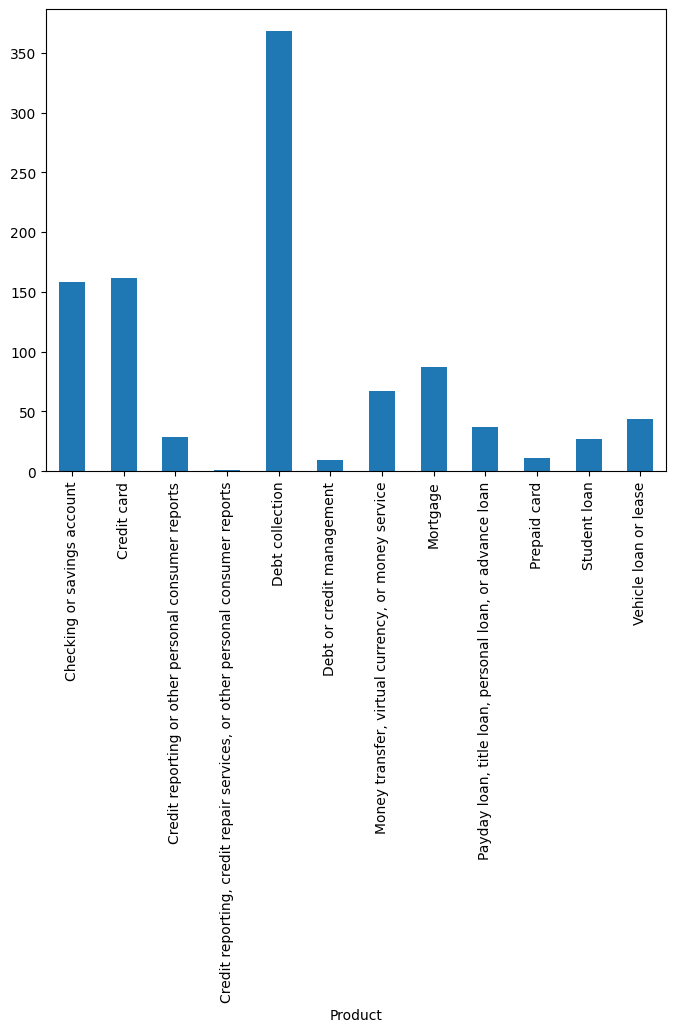

In [8]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,6))
df.groupby('Product').Consumer_complaint_narrative.count().plot.bar(ylim=0)
plt.show()

In [9]:
df.groupby('Product').Consumer_complaint_narrative.count()

,Consumer_complaint_narrative
Product,
Checking or savings account,158
Credit card,162
Credit reporting or other personal consumer reports,29
"Credit reporting, credit repair services, or other personal consumer reports",1
Debt collection,368
Debt or credit management,9
"Money transfer, virtual currency, or money service",67
Mortgage,87
"Payday loan, title loan, personal loan, or advance loan",37


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5, norm='l2', encoding='latin-1', ngram_range=(1, 2), stop_words='english')
features = tfidf.fit_transform(df.Consumer_complaint_narrative).toarray()
labels = df.category_id
features.shape

(1000, 4280)

In [11]:
features

array([[0.03416141, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.09297235, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [12]:
from sklearn.feature_selection import chi2
import numpy as np
N = 2
for Product, category_id in sorted(category_to_id.items()):
  features_chi2 = chi2(features, labels == category_id)
  indices = np.argsort(features_chi2[0])
  feature_names = np.array(tfidf.get_feature_names_out())[indices]
  unigrams = [v for v in feature_names if len(v.split(' ')) == 1]
  bigrams = [v for v in feature_names if len(v.split(' ')) == 2]
  print("# '{}':".format(Product))
  print("  . Most correlated unigrams:\n. {}".format('\n. '.join(unigrams[-N:])))
  print("  . Most correlated bigrams:\n. {}".format('\n. '.join(bigrams[-N:])))

# 'Bank account or service':
  . Most correlated unigrams:
. documentary
. documentation
  . Most correlated bigrams:
. documentation necessary
. documentation provided
# 'Checking or savings account':
  . Most correlated unigrams:
. bank
. chime
  . Most correlated bigrams:
. checking account
. wells fargo
# 'Consumer Loan':
  . Most correlated unigrams:
. documentary
. documentation
  . Most correlated bigrams:
. documentation necessary
. documentation provided
# 'Credit card':
  . Most correlated unigrams:
. synchrony
. card
  . Most correlated bigrams:
. synchrony bank
. credit card
# 'Credit card or prepaid card':
  . Most correlated unigrams:
. documentary
. documentation
  . Most correlated bigrams:
. documentation necessary
. documentation provided
# 'Credit reporting':
  . Most correlated unigrams:
. documentary
. documentation
  . Most correlated bigrams:
. documentation necessary
. documentation provided
# 'Credit reporting or other personal consumer reports':
  . Most corre

In [13]:
# Naive Bayes Classifier: the one most suitable for word counts is the multinomial variant:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.naive_bayes import MultinomialNB

count_vect = CountVectorizer()

X_train, X_test, y_train, y_test = train_test_split(df['Consumer_complaint_narrative'], df['Product'], random_state = 0)

In [14]:
X_train.count()

np.int64(750)

In [15]:
X_test

,Consumer_complaint_narrative
9308,I have a XXXX XXXX XXXX financed through Santa...
7685,I am filing this consumer complaint against XX...
3337,"Trans World Systems , Inc. keeps calling me to..."
5131,"When I tried to request my card, the Next butt..."
6011,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX, MI XX..."
...,...
4466,JEFFERSON CAPITAL SYST is falsely reporting on...
3533,"On XX/XX/year>, I used mobile deposit to depos..."
2,I have a long time victim of fraud and identit...
4592,Jefferson Capital LLC Jefferson Capital System...


In [16]:
y_train.count()

np.int64(750)

In [17]:
y_test.count()

np.int64(250)

In [18]:
#Term Frecuency - TF
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)

In [19]:
print(X_train_counts)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 82430 stored elements and shape (750, 6857)>
  Coords	Values
  (0, 629)	2
  (0, 2556)	1
  (0, 6091)	5
  (0, 1451)	1
  (0, 545)	1
  (0, 6374)	7
  (0, 3146)	1
  (0, 2636)	3
  (0, 1587)	1
  (0, 1791)	13
  (0, 1394)	15
  (0, 466)	6
  (0, 539)	4
  (0, 4889)	3
  (0, 3955)	8
  (0, 6129)	4
  (0, 6783)	7
  (0, 2063)	9
  (0, 652)	11
  (0, 2473)	1
  (0, 6149)	9
  (0, 4745)	2
  (0, 668)	3
  (0, 6516)	3
  (0, 4174)	10
  :	:
  (749, 643)	1
  (749, 4398)	1
  (749, 6612)	1
  (749, 2691)	1
  (749, 6701)	1
  (749, 6109)	1
  (749, 6511)	1
  (749, 2663)	1
  (749, 6844)	1
  (749, 3690)	1
  (749, 5117)	1
  (749, 3972)	1
  (749, 5541)	1
  (749, 431)	1
  (749, 2271)	1
  (749, 1698)	1
  (749, 3156)	1
  (749, 3793)	1
  (749, 761)	2
  (749, 3878)	1
  (749, 5199)	1
  (749, 4891)	1
  (749, 4913)	1
  (749, 1522)	1
  (749, 4387)	1


In [20]:
tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

In [21]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 82430 stored elements and shape (750, 6857)>
  Coords	Values
  (0, 0)	0.016996046172286994
  (0, 42)	0.03125716163782636
  (0, 69)	0.04071169204723793
  (0, 346)	0.06226015728773939
  (0, 371)	0.024276104743611165
  (0, 413)	0.03702479470726439
  (0, 453)	0.045429086284786147
  (0, 457)	0.02846047851319108
  (0, 466)	0.17203159897886883
  (0, 539)	0.08553833355273081
  (0, 545)	0.026167300816062902
  (0, 548)	0.02856558389837937
  (0, 591)	0.03434566734052742
  (0, 595)	0.15146885223439072
  (0, 596)	0.04112973988747001
  (0, 629)	0.029934952242450307
  (0, 648)	0.014580169193510566
  (0, 652)	0.1034302123363098
  (0, 668)	0.05125201557272871
  (0, 693)	0.034689381875353684
  (0, 717)	0.030439652123223988
  (0, 788)	0.03281039767227335
  (0, 887)	0.021823031709345797
  (0, 930)	0.021057768900000128
  (0, 935)	0.017568238580744126
  :	:
  (749, 4745)	0.06801578477526252
  (749, 4885)	0.06841277293311977
  (749, 4891)	0.123361

In [22]:
y_train.count()

np.int64(750)

In [23]:
clf = MultinomialNB().fit(X_train_tfidf, y_train)

In [24]:
print(clf)

MultinomialNB()


In [25]:
print(clf.predict(count_vect.transform(["This company refuses to provide me verification and validation of debt per my right under the FDCPA. I do not believe this debt is mine."])))

['Debt collection']


In [26]:
# Naive Bayes Classifier: the one most suitable for word counts is the multinomial variant:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.naive_bayes import MultinomialNB

import pickle

X_train, X_test, y_train, y_test = train_test_split(df['Consumer_complaint_narrative'], df['Product'], random_state = 0)

count_vect = CountVectorizer()

X_train_counts = count_vect.fit_transform(X_train)

tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

clf = MultinomialNB().fit(X_train_tfidf, y_train)

pickle.dump(clf,open("file.model","wb"))

#clf = pickle.load(open("file.model", 'rb'))
#result = clf.score(X_test, Y_test)


In [27]:
#After fitting the training set, let’s make some predictions.
print(clf.predict(count_vect.transform(["This company refuses to provide me verification and validation of debt per my right under the FDCPA. I do not believe this debt is mine."])))

['Debt collection']


In [28]:
print(clf.predict(count_vect.transform(["I am disputing the inaccurate information the Chex-Systems has on my credit report. I initially submitted a police report on XXXX/XXXX/16 and Chex Systems only deleted the items that I mentioned in the letter and not all \n the items that were actually listed on the police report. In other words they wanted me to say word for word to them what items were fraudulent. The total disregard of the police report and what accounts that it states that are fraudulent. If they just had paid a little closer attention to the police report I would not been in this position now and they would n't have to research once again. I would like the reported information to be removed : XXXX XXXX XXXX"])))

['Debt collection']


In [ ]:
# RETO:
# evaluar con el conjunto de testing

x_test
y_test

for each x_test:
    salida[] = clf.predict(count_vect.transfor(x_test[]))

evaluación????

    comparar (salida, y_test), precicin, recall, f1-score????, 80% ?????